
# Module 10: Fuzzy Matching & Record Linkage

This notebook demonstrates:
- Character- and token-based similarity
- TF–IDF cosine for multi-word strings
- Blocking → compare → classify → evaluate pipeline
- Threshold tuning with precision–recall and confusion matrices


In [1]:
# !pip install scikit-learn rapidfuzz

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from rapidfuzz import fuzz

plt.rcParams["figure.figsize"] = (6,4)


## Character-based similarity

We implement Levenshtein distance and convert it to a normalized similarity in [0,1].


In [3]:
def levenshtein_distance(a: str, b: str) -> int:
    a, b = a or "", b or ""
    n, m = len(a), len(b)
    if n == 0: return m
    if m == 0: return n
    dp = [list(range(m+1))] + [[i] + [0]*m for i in range(1, n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,      # deletion
                dp[i][j-1] + 1,      # insertion
                dp[i-1][j-1] + cost  # substitution
            )
    return dp[n][m]

def char_similarity(a: str, b: str) -> float:
    a, b = a or "", b or ""
    if not a and not b:
        return 1.0
    dist = levenshtein_distance(a, b)
    return 1.0 - dist / max(len(a), len(b))

In [4]:
examples = [
    ("Wal-Mart", "Walmart"),
    ("St. Johns", "Saint Johns"),
    ("Data Science", "Science Data"),
    ("Tennessee", "tennessee"),
    ("Jon Smith", "John Smyth"),
]

for a, b in examples:
    print(
        f"{a!r} vs {b!r} -> "
        f"char_similarity={char_similarity(a,b):.2f}, "
        f"fuzz_ratio={fuzz.ratio(a,b)/100:.2f}, "
        f"fuzz_partial={fuzz.partial_ratio(a,b)/100:.2f}, "
    )

'Wal-Mart' vs 'Walmart' -> char_similarity=0.75, fuzz_ratio=0.80, fuzz_partial=0.71, 
'St. Johns' vs 'Saint Johns' -> char_similarity=0.64, fuzz_ratio=0.80, fuzz_partial=0.88, 
'Data Science' vs 'Science Data' -> char_similarity=0.17, fuzz_ratio=0.58, fuzz_partial=0.74, 
'Tennessee' vs 'tennessee' -> char_similarity=0.89, fuzz_ratio=0.89, fuzz_partial=0.94, 
'Jon Smith' vs 'John Smyth' -> char_similarity=0.80, fuzz_ratio=0.84, fuzz_partial=0.78, 



## Token-based similarity

Two ideas:
- **Token sort ratio**: sort tokens alphabetically then compare using character similarity.
- **Token set ratio**: emphasize shared tokens and penalize extras.


In [5]:
import re
_word_re = re.compile(r"[A-Za-z0-9_-]+")

def tokenize(s: str):
    return _word_re.findall((s or "").lower())

def token_sort_ratio(a: str, b: str) -> float:
    ta = " ".join(sorted(tokenize(a)))
    tb = " ".join(sorted(tokenize(b)))
    return char_similarity(ta, tb)

def token_set_ratio(a: str, b: str) -> float:
    A, B = set(tokenize(a)), set(tokenize(b))
    if not A and not B:
        return 1.0

    inter = " ".join(sorted(A & B))
    a_comb = " ".join(sorted(A))
    b_comb = " ".join(sorted(B))
    inter_a = " ".join(sorted(A & B) + sorted(A - B))
    inter_b = " ".join(sorted(A & B) + sorted(B - A))

    return max(
        char_similarity(inter, a_comb),
        char_similarity(inter, b_comb),
        char_similarity(inter_a, inter_b)
    )

In [6]:
pairs = [
    ("University of Tennessee", "Tennessee University"),
    ("University of Tennessee", "University of Tennessee Knoxville"),
    ("UT Knoxville", "University of Tennessee Knoxville"),
    ("Data Science", "Science Data"),
    ("Walmart Inc.", "Wal-Mart Stores")
]

for a, b in pairs:
    print(f"{a!r} vs {b!r}")
    print(f"  token_sort_ratio (custom) = {token_sort_ratio(a,b):.2f}")
    print(f"  token_sort_ratio (fuzz)   = {fuzz.token_sort_ratio(a,b)/100:.2f}")
    print(f"  token_set_ratio  (custom) = {token_set_ratio(a,b):.2f}")
    print(f"  token_set_ratio  (fuzz)   = {fuzz.token_set_ratio(a,b)/100:.2f}")

'University of Tennessee' vs 'Tennessee University'
  token_sort_ratio (custom) = 0.87
  token_sort_ratio (fuzz)   = 0.93
  token_set_ratio  (custom) = 1.00
  token_set_ratio  (fuzz)   = 1.00
'University of Tennessee' vs 'University of Tennessee Knoxville'
  token_sort_ratio (custom) = 0.70
  token_sort_ratio (fuzz)   = 0.82
  token_set_ratio  (custom) = 1.00
  token_set_ratio  (fuzz)   = 1.00
'UT Knoxville' vs 'University of Tennessee Knoxville'
  token_sort_ratio (custom) = 0.36
  token_sort_ratio (fuzz)   = 0.49
  token_set_ratio  (custom) = 0.75
  token_set_ratio  (fuzz)   = 0.86
'Data Science' vs 'Science Data'
  token_sort_ratio (custom) = 1.00
  token_sort_ratio (fuzz)   = 1.00
  token_set_ratio  (custom) = 1.00
  token_set_ratio  (fuzz)   = 1.00
'Walmart Inc.' vs 'Wal-Mart Stores'
  token_sort_ratio (custom) = 0.53
  token_sort_ratio (fuzz)   = 0.52
  token_set_ratio  (custom) = 0.53
  token_set_ratio  (fuzz)   = 0.52



## TF–IDF cosine similarity


In [7]:
texts = [
    "cheap flights to Paris",
    "low-cost Paris flight deals",
    "affordable hotels in Paris",
    "economy tickets to Berlin"
]
vec = TfidfVectorizer()
X = vec.fit_transform(texts)
sim = cosine_similarity(X)
pd.DataFrame(sim, index=texts, columns=texts)

,cheap flights to Paris,low-cost Paris flight deals,affordable hotels in Paris,economy tickets to Berlin
cheap flights to Paris,1.000000,0.111504,0.126815,0.187675
low-cost Paris flight deals,0.111504,1.000000,0.105130,0.000000
affordable hotels in Paris,0.126815,0.105130,1.000000,0.000000
economy tickets to Berlin,0.187675,0.000000,0.000000,1.000000



## Synthetic record linkage dataset

We create two datasets A and B with overlapping entities and realistic noise.


In [8]:
rng = np.random.default_rng(123)

base = pd.DataFrame({
    "entity_id": range(1, 51),
    "name": [
        "John Smith","Jane Doe","Robert Brown","Emily Davis","Michael Johnson",
        "William Wilson","Mary Clark","Patricia Lewis","Jennifer Walker","Linda Hall",
        "Barbara Allen","Elizabeth Young","James Hernandez","David King","Susan Wright",
        "Joseph Lopez","Thomas Hill","Sarah Scott","Charles Green","Karen Adams",
        "Nancy Baker","Lisa Nelson","Betty Carter","Margaret Mitchell","Sandra Perez",
        "Ashley Roberts","Kimberly Turner","Donna Phillips","Michelle Campbell","Carol Parker",
        "Amanda Evans","Melissa Edwards","Deborah Collins","Stephanie Stewart","Rebecca Sanchez",
        "Sharon Morris","Laura Rogers","Cynthia Reed","Kathleen Cook","Amy Morgan",
        "Shirley Bell","Angela Murphy","Helen Bailey","Anna Rivera","Brenda Cooper",
        "Pamela Richardson","Emma Cox","Nicole Howard","Samantha Ward","Katherine Torres"
    ],
    "city": rng.choice(["Knoxville","Nashville","Memphis","Chattanooga"], size=50),
    "zip": rng.choice(["37996","37201","38103","37402"], size=50)
})
A = base.copy()
A["name"] = A["name"].str.replace("William","Will").str.replace("Michael","Mike")

def perturb_name(n):
    n = n.replace("John","Jon") if rng.random()<0.25 else n
    n = n.replace("Smith","Smyth") if rng.random()<0.15 else n
    n = n.replace("Robert","Robt") if rng.random()<0.20 else n
    if rng.random()<0.15:
        parts = n.split()
        n = " ".join(reversed(parts))
    return n

B = base.copy()
B["name"] = B["name"].apply(perturb_name)
mask = rng.random(50) < 0.10
B.loc[mask, "city"] = rng.choice(["Knoxville","Nashville","Memphis","Chattanooga"], size=mask.sum())
mask = rng.random(50) < 0.08
B.loc[mask, "zip"] = rng.choice(["37996","37201","38103","37402"], size=mask.sum())

B = B.sample(frac=1.0, random_state=7).reset_index(drop=True)
B_no_id = B.drop(columns=["entity_id"])

print("A:")
display(A.head())
print("B:")
display(B_no_id.head())

A:


,entity_id,name,city,zip
0,1,John Smith,Knoxville,37201
1,2,Jane Doe,Memphis,37996
2,3,Robert Brown,Memphis,37996
3,4,Emily Davis,Knoxville,37201
4,5,Mike Johnson,Chattanooga,37996


B:


,name,city,zip
0,David King,Chattanooga,37402
1,Joseph Lopez,Knoxville,37996
2,Carter Betty,Nashville,37201
3,Bailey Helen,Knoxville,37201
4,Amanda Evans,Knoxville,38103



## Blocking


In [9]:
def first_letter_last(name):
    parts = (name or "").split()
    return parts[-1][0].upper() if parts else ""

A_blk = A.assign(block_zip=A["zip"], block_last=A["name"].apply(first_letter_last))
B_blk = B_no_id.assign(block_zip=B_no_id["zip"], block_last=B_no_id["name"].apply(first_letter_last))

cand = []
for i, ra in A_blk.iterrows():
    mask = (B_blk["block_zip"] == ra["block_zip"]) | (B_blk["block_last"] == ra["block_last"])
    for j in B_blk[mask].index:
        cand.append((i, j))

# total brute-force comparisons
total_pairs = len(A) * len(B_no_id)

# reduced comparisons after blocking
blocked_pairs = len(cand)

reduction = 1 - blocked_pairs / total_pairs

print(f"Total possible pairs: {total_pairs:,}")
print(f"Candidate pairs after blocking: {blocked_pairs:,}")
print(f"Reduction: {reduction:.1%}")

Total possible pairs: 2,500
Candidate pairs after blocking: 753
Reduction: 69.9%



## Compare and score


In [10]:
def exact_match(a, b):
    return 1.0 if (a or "") == (b or "") else 0.0

rows = []
for i,j in cand:
    ra, rb = A.iloc[i], B_no_id.iloc[j]
    name_char = char_similarity(ra["name"], rb["name"])
    name_tok  = token_sort_ratio(ra["name"], rb["name"])
    city_exact = exact_match(ra["city"], rb["city"])
    zip_exact  = exact_match(ra["zip"],  rb["zip"])
    rows.append((i, j, name_char, name_tok, city_exact, zip_exact))

feat = pd.DataFrame(rows, columns=["i","j","name_char","name_tok","city_exact","zip_exact"])

weights = {"name_char":0.45, "name_tok":0.35, "city_exact":0.10, "zip_exact":0.10}
feat["score"] = (
    weights["name_char"]*feat["name_char"] +
    weights["name_tok"] *feat["name_tok"]  +
    weights["city_exact"]*feat["city_exact"] +
    weights["zip_exact"] *feat["zip_exact"]
)
feat.head()

,i,j,name_char,name_tok,city_exact,zip_exact,score
0,0,2,0.166667,0.166667,0.0,1.0,0.233333
1,0,3,0.083333,0.083333,1.0,1.0,0.266667
2,0,5,0.285714,0.285714,1.0,1.0,0.428571
3,0,10,0.200000,0.266667,0.0,1.0,0.283333
4,0,11,0.100000,0.300000,1.0,1.0,0.350000



## Ground truth and evaluation


In [11]:
A_ids = A["entity_id"].to_numpy()
B_ids = B["entity_id"].to_numpy()

y_true = np.array([1 if A_ids[i] == B_ids[j] else 0 for i,j in feat[["i","j"]].to_numpy()])
scores = feat["score"].to_numpy()

pos_rate = y_true.mean()
n_pairs = len(y_true)
print("Pairs:", n_pairs, "Positive rate:", round(pos_rate, 3))

Pairs: 753 Positive rate: 0.066


In [12]:
true_ids = set(A["entity_id"])        
total_true = len(true_ids)                

# how many true pairs are present in the candidate set
matched_true_ids = set()
for i, j in cand:
    if A.loc[i, "entity_id"] == B.loc[j, "entity_id"]:
        matched_true_ids.add(A.loc[i, "entity_id"])

caught_true = len(matched_true_ids)
recall_blocking = caught_true / total_true

print(f"True matches in data: {total_true}")
print(f"Caught by blocking:   {caught_true}")
print(f"Blocking recall:      {recall_blocking:.1%}")


True matches in data: 50
Caught by blocking:   50
Blocking recall:      100.0%



## Inspect matches


In [13]:
out = feat.copy()
out["y_true"] = y_true
out_sorted = out.sort_values("score", ascending=False)

def view_pairs(df, k=5):
    rows = []
    for _, r in df.head(k).iterrows():
        i, j = int(r["i"]), int(r["j"])
        rows.append({
            "score": round(r["score"], 3),
            "true_match": int(r["y_true"]),
            "A_name": A.loc[i, "name"],
            "B_name": B_no_id.loc[j, "name"],
            "A_city": A.loc[i, "city"],
            "B_city": B_no_id.loc[j, "city"],
            "A_zip": A.loc[i, "zip"],
            "B_zip": B_no_id.loc[j, "zip"],
        })
    return pd.DataFrame(rows)

print("Top matches:")
view_pairs(out_sorted, 60)

Top matches:


,score,true_match,A_name,B_name,A_city,B_city,A_zip,B_zip
0,1.000,1,Samantha Ward,Samantha Ward,Nashville,Nashville,38103,38103
1,1.000,1,Nicole Howard,Nicole Howard,Memphis,Memphis,37201,37201
2,1.000,1,Emma Cox,Emma Cox,Knoxville,Knoxville,37201,37201
3,1.000,1,Jane Doe,Jane Doe,Memphis,Memphis,37996,37996
4,1.000,1,Robert Brown,Robert Brown,Memphis,Memphis,37996,37996
5,1.000,1,Angela Murphy,Angela Murphy,Knoxville,Knoxville,37201,37201
6,1.000,1,Anna Rivera,Anna Rivera,Knoxville,Knoxville,37996,37996
7,1.000,1,Pamela Richardson,Pamela Richardson,Nashville,Nashville,37996,37996
8,1.000,1,Shirley Bell,Shirley Bell,Chattanooga,Chattanooga,38103,38103
9,1.000,1,Amy Morgan,Amy Morgan,Memphis,Memphis,37996,37996



## Threshold tuning: Precision–Recall


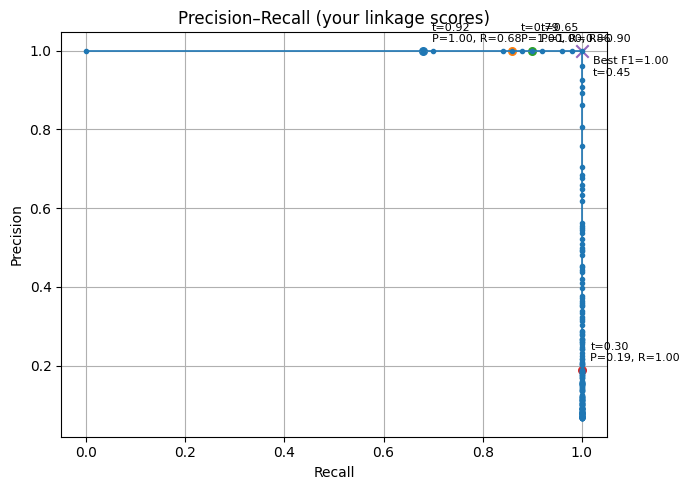

Best threshold: 0.446 | F1=1.000 | P=1.000 | R=1.000


In [14]:

prec, rec, thr = precision_recall_curve(y_true, scores)
ap = average_precision_score(y_true, scores)

def pr_at_t(t):
    i = np.argmin(np.abs(thr - t))
    return prec[i+1], rec[i+1], thr[i]

# pick thresholds you care about
t_list = [0.95, 0.80, 0.65, 0.30]
pts = [pr_at_t(t) for t in t_list]

# best-F1 threshold on your data
uniq_t = np.unique(np.round(scores, 4))
best = (-1, None, None, None)  # f1, t, p, r
for t in uniq_t:
    y_pred = (scores >= t).astype(int)
    p = (y_true[y_pred==1].sum() / max((y_pred==1).sum(), 1)) if (y_pred==1).sum() else 1.0
    r = (y_pred[y_true==1].sum() / (y_true==1).sum())
    f1 = f1_score(y_true, y_pred)
    if f1 > best[0]:
        best = (f1, t, p, r)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, marker='.', linewidth=1.2, label=f'PR (AP={ap:.2f})')

for p, r, t in pts:
    plt.scatter(r, p, s=30)
    plt.annotate(f't={t:.2f}\nP={p:.2f}, R={r:.2f}',
                 xy=(r, p), xytext=(6, 6), textcoords='offset points', fontsize=8)

plt.scatter(best[3], best[2], marker='x', s=80)
plt.annotate(f'Best F1={best[0]:.2f}\nt={best[1]:.2f}',
             xy=(best[3], best[2]), xytext=(8, -18), textcoords='offset points', fontsize=8)

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall (your linkage scores)')
plt.grid(True); plt.tight_layout(); plt.show()

print(f"Best threshold: {best[1]:.3f} | F1={best[0]:.3f} | P={best[2]:.3f} | R={best[3]:.3f}")



## Confusion matrices at selected thresholds


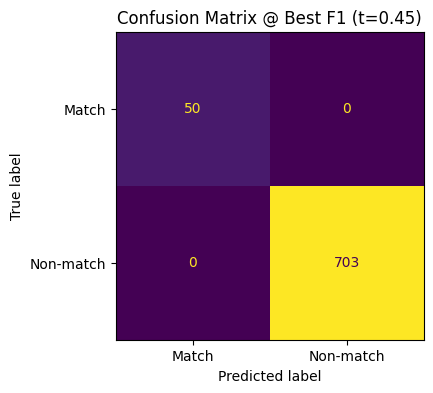

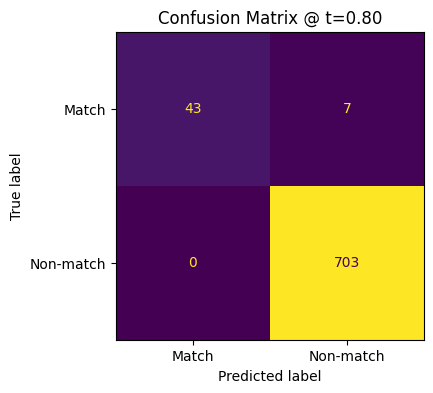

In [15]:
# --- Confusion matrix at best-F1 threshold ---
t_best = float(best[1])
y_pred_best = (scores >= t_best).astype(int)
cm_best = confusion_matrix(y_true, y_pred_best, labels=[1, 0])

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                              display_labels=["Match", "Non-match"])
disp.plot(ax=ax, colorbar=False)
plt.title(f"Confusion Matrix @ Best F1 (t={t_best:.2f})")
plt.show()

# --- Optional: confusion matrix at a fixed threshold (e.g., 0.80) ---
t_fixed = 0.80
y_pred_fixed = (scores >= t_fixed).astype(int)
cm_fixed = confusion_matrix(y_true, y_pred_fixed, labels=[1, 0])

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fixed,
                              display_labels=["Match", "Non-match"])
disp.plot(ax=ax, colorbar=False)
plt.title(f"Confusion Matrix @ t={t_fixed:.2f}")
plt.show()